# Agentic AI — Assignment Alpha
## Q4: Eco-Friendly Intelligent Agents

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

Notebook setup complete.


---
# Part A — Simple Reflex Agent for Abnormal Crowd Movement

### PEAS

| Component | Description |
|---|---|
| **Performance** | Detect abnormal movement correctly while minimizing power usage |
| **Environment** | Crowd in a station, campus, mall, or public area |
| **Actuators** | Raise alert, activate high-resolution verification camera |
| **Sensors** | Low-power camera / motion sensor measuring speed and movement direction |

### Condition–action rules

1. If speed \(>3.0\) m/s → **ALERT: RUNNING**
2. If direction differs from normal crowd flow by \(>120^\circ\) and speed \(>0.8\) m/s → **ALERT: COUNTERFLOW**
3. Otherwise → **NORMAL**

The agent is eco-friendly because the low-power sensor remains active continuously while expensive high-power verification is activated only when necessary.

In [ ]:
# Example percepts
crowd_data = pd.DataFrame({
    "Person": ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"],
    "Speed_mps": [1.2, 1.5, 4.2, 1.1, 3.8, 1.4, 1.0, 2.0],
    "Direction_Deviation_deg": [10, 25, 20, 170, 35, 15, 150, 40]
})

def reflex_agent(speed, direction_deviation):
    if speed > 3.0:
        return "ALERT_RUNNING"
    elif direction_deviation > 120 and speed > 0.8:
        return "ALERT_COUNTERFLOW"
    return "NORMAL"

crowd_data["Action"] = [
    reflex_agent(s, d)
    for s, d in zip(crowd_data["Speed_mps"], crowd_data["Direction_Deviation_deg"])
]

display(crowd_data)

,Person,Speed_mps,Direction_Deviation_deg,Action
0,P1,1.2,10,NORMAL
1,P2,1.5,25,NORMAL
2,P3,4.2,20,ALERT_RUNNING
3,P4,1.1,170,ALERT_COUNTERFLOW
4,P5,3.8,35,ALERT_RUNNING
5,P6,1.4,15,NORMAL
6,P7,1.0,150,ALERT_COUNTERFLOW
7,P8,2.0,40,NORMAL


In [ ]:
# Eco-footprint illustration
# Assumptions:
# Conventional high-resolution camera + processor = 150 W continuously
# Eco low-power sensing = 5 W continuously
# Verification adds 45 W only when at least one alert is active
# Assume verification is active 2% of a typical day.

baseline_power_w = 150
eco_idle_w = 5
verification_extra_w = 45
alert_duty = 0.02

eco_avg_power_w = eco_idle_w + verification_extra_w * alert_duty

baseline_kwh_day = baseline_power_w * 24 / 1000
eco_kwh_day = eco_avg_power_w * 24 / 1000

co2_per_kwh_g = 450   # explicit simulation assumption
water_per_kwh_l = 1.9 # explicit simulation assumption

part_a = pd.DataFrame({
    "System": ["Conventional", "Eco Reflex Agent"],
    "Average Power (W)": [baseline_power_w, eco_avg_power_w],
    "Energy (kWh/day)": [baseline_kwh_day, eco_kwh_day],
    "CO2 (g/day)": [baseline_kwh_day*co2_per_kwh_g, eco_kwh_day*co2_per_kwh_g],
    "Water (L/day)": [baseline_kwh_day*water_per_kwh_l, eco_kwh_day*water_per_kwh_l]
})
display(part_a.round(3))

co2_save_A = 1 - part_a.loc[1, "CO2 (g/day)"] / part_a.loc[0, "CO2 (g/day)"]
water_save_A = 1 - part_a.loc[1, "Water (L/day)"] / part_a.loc[0, "Water (L/day)"]

print(f"Estimated CO2 reduction = {co2_save_A:.1%}")
print(f"Estimated water reduction = {water_save_A:.1%}")

,System,Average Power (W),Energy (kWh/day),CO2 (g/day),Water (L/day)
0,Conventional,150.0,3.600,1620.00,6.840
1,Eco Reflex Agent,5.9,0.142,63.72,0.269


Estimated CO2 reduction = 96.1%
Estimated water reduction = 96.1%


---
# Part B — Utility-Based Agent for Stressed / Tense Patients

### PEAS

| Component | Description |
|---|---|
| **Performance** | Reduce stress and improve comfort while minimizing resource use |
| **Environment** | Hospital ward, clinic, waiting room |
| **Actuators** | Breathing exercise, music, nurse alert, HVAC adjustment, warm shower |
| **Sensors** | Stress score, heart rate / HRV, patient preferences |

The agent evaluates possible actions using:

\[
Utility =
ExpectedStressReduction
+ Comfort
- CO_2Cost
- WaterCost
\]

and selects the feasible action with maximum utility.

In [ ]:
actions = pd.DataFrame([
    # action, expected stress reduction, comfort, CO2 g, water L
    ("Guided breathing",          2.0, 0.5,   4,  0.0),
    ("Calming music",             1.5, 1.0,   8,  0.0),
    ("Nurse conversation",        3.0, 2.0,  10,  0.0),
    ("HVAC cooling",              0.8, 1.0, 400,  0.0),
    ("Warm shower",               2.0, 2.0, 600, 40.0),
    ("Escalate to clinician",     4.5, 0.0,   8,  0.0),
], columns=["Action", "Stress_Reduction", "Comfort", "CO2_g", "Water_L"]).set_index("Action")

# Weights are explicit assumptions for the simulation
W_STRESS = 1.0
W_COMFORT = 0.4
W_CO2 = 0.004
W_WATER = 0.04

def utility(row):
    return (
        W_STRESS * row["Stress_Reduction"]
        + W_COMFORT * row["Comfort"]
        - W_CO2 * row["CO2_g"]
        - W_WATER * row["Water_L"]
    )

actions["Utility"] = actions.apply(utility, axis=1)
display(actions.sort_values("Utility", ascending=False).round(3))

,Stress_Reduction,Comfort,CO2_g,Water_L,Utility
Action,,,,,
Escalate to clinician,4.5,0.0,8,0.0,4.468
Nurse conversation,3.0,2.0,10,0.0,3.760
Guided breathing,2.0,0.5,4,0.0,2.184
Calming music,1.5,1.0,8,0.0,1.868
HVAC cooling,0.8,1.0,400,0.0,-0.400
Warm shower,2.0,2.0,600,40.0,-1.200


In [ ]:
patients = pd.DataFrame({
    "Patient": ["Patient 1", "Patient 2", "Patient 3"],
    "Stress_Score": [5, 7, 9]
})

def choose_patient_action(stress):
    candidates = actions.copy()

    # Only severe stress should trigger clinician escalation.
    if stress < 8:
        candidates = candidates.drop(index="Escalate to clinician")

    # For mild/moderate stress, avoid unnecessarily resource-heavy actions if
    # a positive-utility low-footprint option exists.
    best_action = candidates["Utility"].idxmax()
    return best_action

patients["Selected_Action"] = patients["Stress_Score"].apply(choose_patient_action)
patients["Utility"] = patients["Selected_Action"].map(actions["Utility"])
patients["CO2_g"] = patients["Selected_Action"].map(actions["CO2_g"])
patients["Water_L"] = patients["Selected_Action"].map(actions["Water_L"])

display(patients.round(3))

,Patient,Stress_Score,Selected_Action,Utility,CO2_g,Water_L
0,Patient 1,5,Nurse conversation,3.760,10,0.0
1,Patient 2,7,Nurse conversation,3.760,10,0.0
2,Patient 3,9,Escalate to clinician,4.468,8,0.0


The utility-based agent explicitly balances **patient benefit** against environmental cost. High-resource actions such as continuous HVAC changes or warm showers are not selected unless their benefit justifies their cost.

---
# Part C — Goal-Based Agent for a Secure School-Van Network

### PEAS

| Component | Description |
|---|---|
| **Performance** | Pick up all students and reach school safely with low distance/fuel use |
| **Environment** | Road network, pickup stops, traffic/risk levels |
| **Actuators** | Drive to a connected location |
| **Sensors** | Map, road distance, road risk, current location |

### Goal

\[
\boxed{\text{Visit all required pickup points and reach School}}
\]

We use a cost that combines distance and road risk:

\[
Cost(edge)=Distance\times(1+\lambda\,Risk)
\]

Roads above the safety threshold are forbidden.

In [ ]:
# Small road network for the demonstration
roads = {
    "Depot": [("A", 2.0, 0.10), ("B", 2.5, 0.15)],
    "A": [("Depot", 2.0, 0.10), ("C", 2.0, 0.20), ("School", 5.5, 0.15)],
    "B": [("Depot", 2.5, 0.15), ("C", 1.5, 0.25), ("School", 4.0, 0.80)],
    "C": [("A", 2.0, 0.20), ("B", 1.5, 0.25), ("School", 2.5, 0.10)],
    "School": [("A", 5.5, 0.15), ("B", 4.0, 0.80), ("C", 2.5, 0.10)]
}

required_stops = {"A", "B", "C"}
risk_limit = 0.60
lambda_risk = 2.0

In [ ]:
def edge_cost(distance, risk):
    return distance * (1 + lambda_risk * risk)

def goal_based_search():
    # State = (current_location, frozenset(visited_pickups))
    start = ("Depot", frozenset())
    pq = [(0.0, "Depot", frozenset(), ["Depot"])]
    best = {start: 0.0}

    while pq:
        cost, node, visited, path = heapq.heappop(pq)

        if node == "School" and visited == required_stops:
            return cost, path

        if cost > best.get((node, visited), float("inf")):
            continue

        for nxt, distance, risk in roads[node]:
            if risk > risk_limit:
                continue  # secure-commute constraint

            # School is allowed only after every pickup has been visited
            if nxt == "School" and visited != required_stops:
                continue

            new_visited = visited
            if nxt in required_stops:
                new_visited = visited | {nxt}

            new_cost = cost + edge_cost(distance, risk)
            state = (nxt, new_visited)

            if new_cost < best.get(state, float("inf")):
                best[state] = new_cost
                heapq.heappush(pq, (new_cost, nxt, new_visited, path + [nxt]))

    return None, None

goal_cost, goal_path = goal_based_search()

print("Selected secure route:", " -> ".join(goal_path))
print(f"Risk-adjusted route cost = {goal_cost:.2f}")

Selected secure route: Depot -> A -> C -> B -> C -> School
Risk-adjusted route cost = 12.70


In [ ]:
# Calculate actual route distance, CO2, and water
def road_info(a, b):
    for nxt, distance, risk in roads[a]:
        if nxt == b:
            return distance, risk
    raise ValueError("Road not found")

distance_total = 0
risk_exposure = 0
for a, b in zip(goal_path[:-1], goal_path[1:]):
    d, r = road_info(a, b)
    distance_total += d
    risk_exposure += d * r

van_co2_g_km = 270   # explicit simulation assumption
van_water_l_km = 0.6

print(f"Actual route distance = {distance_total:.2f} km")
print(f"Risk exposure = {risk_exposure:.2f}")
print(f"Estimated CO2 = {distance_total*van_co2_g_km:.1f} g")
print(f"Estimated water = {distance_total*van_water_l_km:.2f} L")

Actual route distance = 9.50 km
Risk exposure = 1.60
Estimated CO2 = 2565.0 g
Estimated water = 5.70 L


The goal-based agent differs from a reflex agent because it does not select an action only from the current percept. It **searches ahead** for a sequence of actions that satisfies the goal under safety and eco constraints.

---
# Part D — Learning Agent to Encourage Sports Activities

### PEAS

| Component | Description |
|---|---|
| **Performance** | Increase sports participation while preferring low-footprint activities |
| **Environment** | Young people with different activity preferences |
| **Actuators** | Recommend an activity |
| **Sensors** | User profile and feedback: accepted / rejected recommendation |

### Learning-agent components

- **Performance element:** selects an activity
- **Critic:** gives a reward from user feedback and eco cost
- **Learning element:** updates estimated action values
- **Problem generator:** explores alternatives using \(\epsilon\)-greedy selection

A simple multi-armed bandit is sufficient because one recommendation is made at a time.

In [ ]:
activities = pd.DataFrame({
    "Activity": ["Walking", "Street Cricket", "Home Workout", "Gym", "Swimming"],
    "True_Acceptance_Probability": [0.55, 0.78, 0.68, 0.75, 0.72],
    "CO2_g": [0, 5, 30, 700, 900],
    "Water_L": [0, 2, 0.5, 15, 60]
}).set_index("Activity")

display(activities)

,True_Acceptance_Probability,CO2_g,Water_L
Activity,,,
Walking,0.55,0,0.0
Street Cricket,0.78,5,2.0
Home Workout,0.68,30,0.5
Gym,0.75,700,15.0
Swimming,0.72,900,60.0


In [ ]:
# Eco-aware reward:
# reward = engagement - lambda * normalized environmental cost

max_co2 = activities["CO2_g"].max()
max_water = activities["Water_L"].max()

activities["Eco_Cost"] = (
    0.5 * activities["CO2_g"] / max_co2
    + 0.5 * activities["Water_L"] / max_water
)

display(activities.round(3))

,True_Acceptance_Probability,CO2_g,Water_L,Eco_Cost
Activity,,,,
Walking,0.55,0,0.0,0.000
Street Cricket,0.78,5,2.0,0.019
Home Workout,0.68,30,0.5,0.021
Gym,0.75,700,15.0,0.514
Swimming,0.72,900,60.0,1.000


In [ ]:
rng = np.random.default_rng(7)

action_names = list(activities.index)
n_actions = len(action_names)

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

epsilon = 0.15
eco_lambda = 0.45
episodes = 3000

reward_history = []
chosen_history = []

for episode in range(episodes):
    # Problem generator: epsilon-greedy exploration
    if rng.random() < epsilon:
        a = rng.integers(n_actions)
    else:
        a = int(np.argmax(Q))

    activity = action_names[a]
    acceptance_p = activities.loc[activity, "True_Acceptance_Probability"]

    engaged = 1 if rng.random() < acceptance_p else 0

    # Critic: combine engagement with environmental cost
    eco_cost = activities.loc[activity, "Eco_Cost"]
    reward = engaged - eco_lambda * eco_cost

    # Learning element: incremental sample-average update
    N[a] += 1
    Q[a] += (reward - Q[a]) / N[a]

    reward_history.append(reward)
    chosen_history.append(activity)

learned = pd.DataFrame({
    "Activity": action_names,
    "Estimated_Q": Q,
    "Times_Selected": N.astype(int),
    "CO2_g": [activities.loc[a, "CO2_g"] for a in action_names],
    "Water_L": [activities.loc[a, "Water_L"] for a in action_names]
}).sort_values("Estimated_Q", ascending=False)

display(learned.round(3))

best_activity = learned.iloc[0]["Activity"]
print("Learned best recommendation:", best_activity)

,Activity,Estimated_Q,Times_Selected,CO2_g,Water_L
1,Street Cricket,0.765,2507,5,2.0
2,Home Workout,0.592,128,30,0.5
3,Gym,0.519,84,700,15.0
0,Walking,0.474,154,0,0.0
4,Swimming,0.322,127,900,60.0


Learned best recommendation: Street Cricket


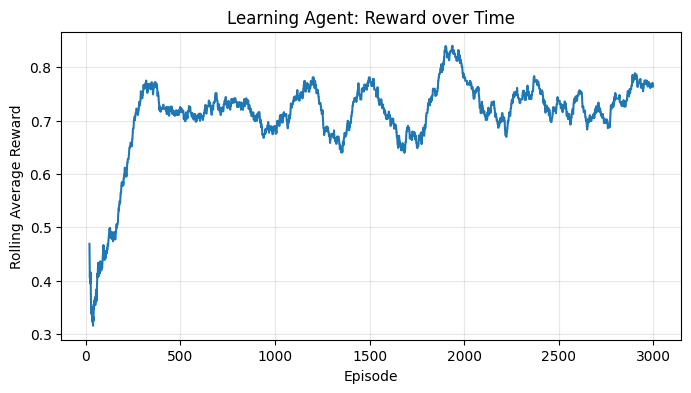

In [ ]:
# Show how the average reward changes during learning
rolling_reward = pd.Series(reward_history).rolling(150, min_periods=20).mean()

plt.figure(figsize=(8, 4))
plt.plot(rolling_reward)
plt.xlabel("Episode")
plt.ylabel("Rolling Average Reward")
plt.title("Learning Agent: Reward over Time")
plt.grid(alpha=0.3)
plt.show()

---
# Final Comparison of the Four Agents

In [ ]:
summary = pd.DataFrame({
    "Agent": [
        "Reflex — Crowd",
        "Utility-Based — Patients",
        "Goal-Based — School Van",
        "Learning — Sports"
    ],
    "Decision Basis": [
        "Current percept + condition-action rules",
        "Maximum utility",
        "Search toward a goal under constraints",
        "Experience / feedback"
    ],
    "Eco Mechanism": [
        "Low-power sensing and event-triggered high-power processing",
        "Environmental cost included in utility",
        "Safe, distance/fuel-aware route planning",
        "Eco-cost included in learned reward"
    ]
})

display(summary)

,Agent,Decision Basis,Eco Mechanism
0,Reflex — Crowd,Current percept + condition-action rules,Low-power sensing and event-triggered high-pow...
1,Utility-Based — Patients,Maximum utility,Environmental cost included in utility
2,Goal-Based — School Van,Search toward a goal under constraints,"Safe, distance/fuel-aware route planning"
3,Learning — Sports,Experience / feedback,Eco-cost included in learned reward


## Conclusion

The four implementations demonstrate the defining behaviour of each agent type:

- A **reflex agent** reacts immediately using fixed rules.
- A **utility-based agent** compares alternative actions numerically.
- A **goal-based agent** searches for a sequence of actions that satisfies a goal.
- A **learning agent** improves its choices from feedback.

In each case, CO₂ and/or water consumption is incorporated into the sensing strategy, utility function, search cost, or reward function so that the agent's behaviour is explicitly eco-friendly.